## Assignment: $k$ Means Clustering


**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

**Q2.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the spending?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

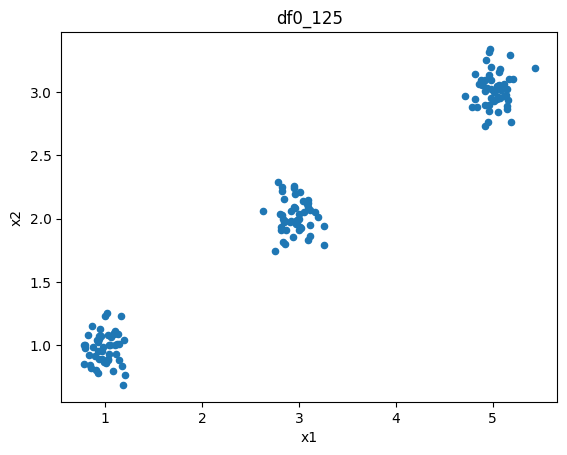

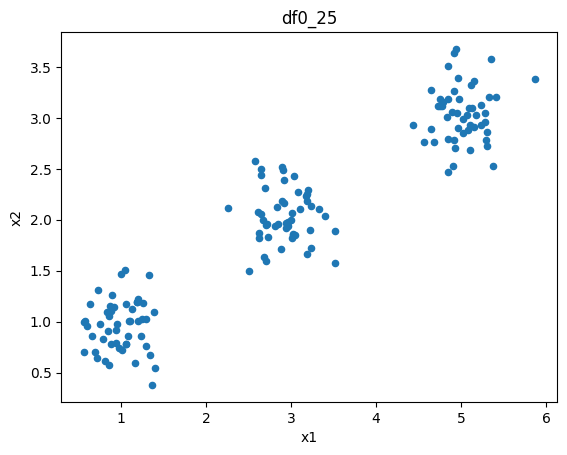

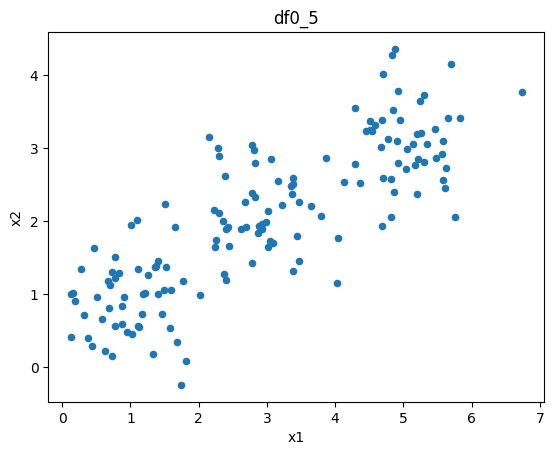

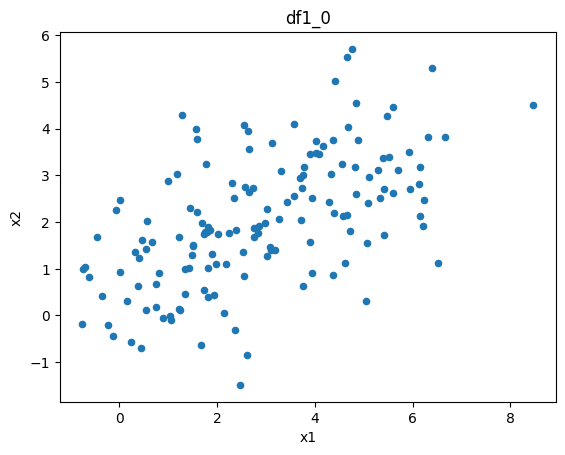

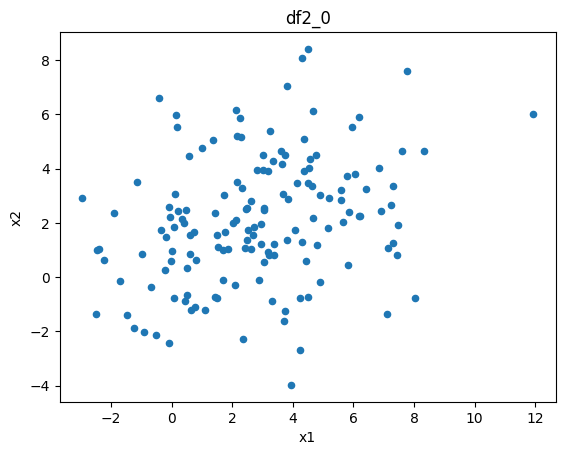


Looking at the scatterplots, the visual distinctness of the clusters diminishes
as the amount of noise in the dataset increases from 0.125 to 2.0. In other words,
the points become more dispersed rather than concentrated, making each individual cluster
harder to distinguish from the other.



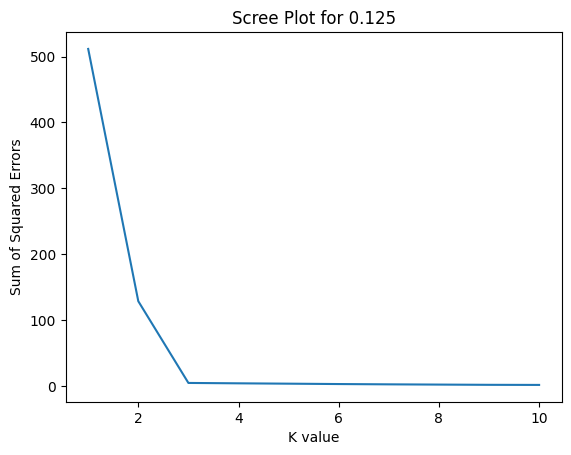

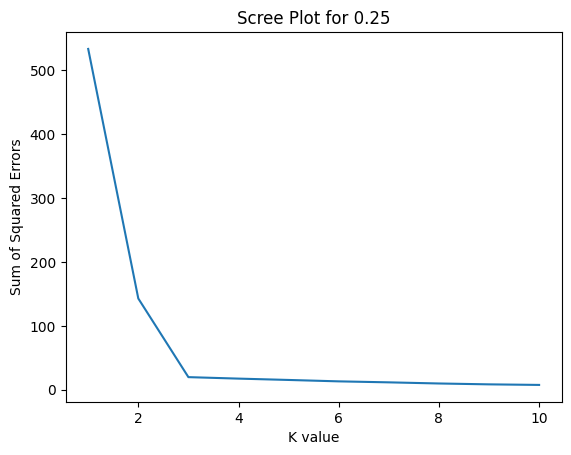

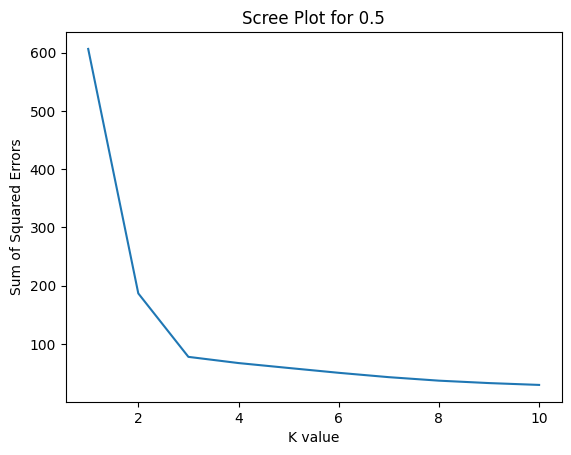

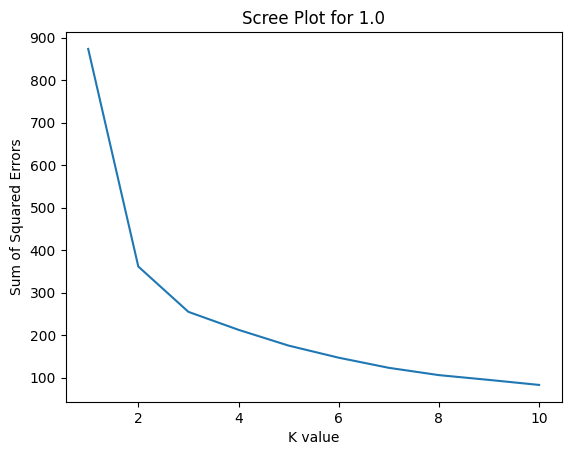

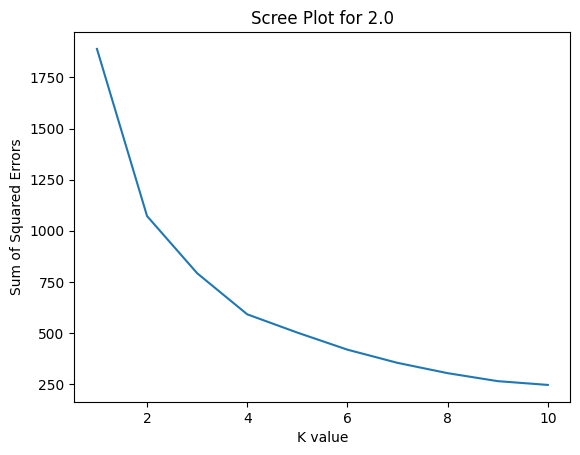


As seen from the scree plots, higher levels of noise make an eblow point less discernable,
with each line plot becoming smoother around the drop-off zone (i.e. the point(s) on the line
at which the SSE drastically drops) from 0.125 to 2.0 noise. For example, at Noise level 0.125,
the elbow is almost certainly located at k = 3. Conversely, the elbow point for Noise Level 2.0
could be any k-value between 3 and 5--this is because there is not as harsh of an inflection point
for decrease in SSE, making it harder to select which of them would be the most correct candidate.


The elbow point signals a k-value when decreases in error, more specifically SSE, for a given set of k-values
drastically slows down. For example, in the numerical simulations above, elbow points would be the following
k-values:
  - 0.125: 3
  - 0.25: 3
  - 0.5: 3
  - 1.0: 3 or 4
  - 2.0: 3,4 or 5
matching these values to the graphs, one can see that these points represent when the SSE--the y-axis--continues to derease

In [54]:
# Your Phase 1 solution to the problem goes here.

# QUESTION 1

# Q1.1
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

# Q1.2
import matplotlib.pyplot as plt

df0_125.plot.scatter(x='x1', y='x2', title =  "df0_125")
plt.show()
df0_25.plot.scatter(x='x1', y='x2', title =  "df0_25")
plt.show()
df0_5.plot.scatter(x='x1', y='x2', title =  "df0_5")
plt.show()
df1_0.plot.scatter(x='x1', y='x2', title =  "df1_0")
plt.show()
df2_0.plot.scatter(x='x1', y='x2', title =  "df2_0")
plt.show()

print("""
Looking at the scatterplots, the visual distinctness of the clusters diminishes
as the amount of noise in the dataset increases from 0.125 to 2.0. In other words,
the points become more dispersed rather than concentrated, making each individual cluster
harder to distinguish from the other.
""")

# Q1.3
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Drop group column because it is non-numeric and rename dataset to X_i
X_1 = df0_125.drop(columns=["group"])
X_2 = df0_25.drop(columns=["group"])
X_3 = df0_5.drop(columns=["group"])
X_4 = df1_0.drop(columns=["group"])
X_5 = df2_0.drop(columns=["group"])

# 0.125
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_1).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.125")
plt.show()

# 0.25
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_2).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.25")
plt.show()

# 0.5
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_3).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.5")
plt.show()


# 1.0
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_4).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 1.0")
plt.show()

# 2.0

ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_5).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 2.0")
plt.show()

print("""
As seen from the scree plots, higher levels of noise make an eblow point less discernable,
with each line plot becoming smoother around the drop-off zone (i.e. the point(s) on the line
at which the SSE drastically drops) from 0.125 to 2.0 noise. For example, at Noise level 0.125,
the elbow is almost certainly located at k = 3. Conversely, the elbow point for Noise Level 2.0
could be any k-value between 3 and 5--this is because there is not as harsh of an inflection point
for decrease in SSE, making it harder to select which of them would be the most correct candidate.
""")

# Q1.4
print("""
The elbow point signals a k-value when decreases in error, more specifically SSE, for a given set of k-values
drastically slows down. For example, in the numerical simulations above, elbow points would be the following
k-values:
  - 0.125: 3
  - 0.25: 3
  - 0.5: 3
  - 1.0: 3 or 4
  - 2.0: 3,4 or 5
matching these values to the graphs, one can see that these points represent when the SSE--the y-axis--continues to derease
but much more slowly following them. There are two main concerns that are addressed by utilizing the
elbow point during a k-Means procedure: firstly, it avoids using a k-value that would yield diminishing returns for SSE. Secondly, it helps reduce
the risk of selecting a k-value that overfits the data; in other words, the selected value of k should be accurate but also generalizable,
and higher values of k risk losing the generalizability by matching too closely to the training datapoints rather than simply
capturing the underlying structure. An elbow point maximizes the compactness of the clusters by identifying when SSE steeply declines
whilst avoiding larger k-values that make redundant improvements to error reduction and can risk the model's ability to
accurately cluster different data sets.

""")




In [2]:
# QUESTION 2

!git clone https://github.com/Matthew-Calvario/A04-clustering.git

Cloning into 'A04-clustering'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 397.11 KiB | 2.09 MiB/s, done.
Resolving deltas: 100% (3/3), done.


Number of NaN values: index                             0
Year                              0
Country                           0
Spending (2020 USD)               0
Percent of GDP                    0
Percent of Government Spending    0
Spending per Capita               0
dtype: int64


,index,Year,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
count,148.000000,148.0,148.000000,148.000000,148.000000,148.000000
mean,2831.256757,2020.0,13153.747670,0.019619,0.061510,268.264494
std,1654.299355,0.0,68005.236120,0.015033,0.046207,430.434878
min,32.000000,2020.0,8.622460,0.000054,0.004896,0.580129
25%,1409.000000,2020.0,204.877177,0.010413,0.031352,20.553464
50%,2871.000000,2020.0,959.535443,0.015324,0.047402,81.506703
75%,4222.500000,2020.0,5289.998320,0.024327,0.084681,326.267753
max,5880.000000,2020.0,778397.200000,0.098470,0.303027,2520.398541


,index,Year,Country,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
32,32,2020,Afghanistan,279.576955,0.013589,0.049728,7.181899
66,66,2020,Albania,187.433234,0.012583,0.037952,65.126211
100,100,2020,Algeria,9708.277440,0.066600,0.173924,221.392384
134,134,2020,Angola,993.594405,0.014442,0.074624,30.231680
168,168,2020,Argentina,2830.929705,0.007269,0.017268,62.636731


Percentage of zeros: index                             0.0
Year                              0.0
Country                           0.0
Spending (2020 USD)               0.0
Percent of GDP                    0.0
Percent of Government Spending    0.0
Spending per Capita               0.0
dtype: float64
Number of duplicates: 0


,index,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita
count,148.000000,148.000000,148.000000,148.000000,148.000000
mean,2831.256757,13153.747670,0.019619,0.061510,268.264494
std,1654.299355,68005.236120,0.015033,0.046207,430.434878
min,32.000000,8.622460,0.000054,0.004896,0.580129
25%,1409.000000,204.877177,0.010413,0.031352,20.553464
50%,2871.000000,959.535443,0.015324,0.047402,81.506703
75%,4222.500000,5289.998320,0.024327,0.084681,326.267753
max,5880.000000,778397.200000,0.098470,0.303027,2520.398541


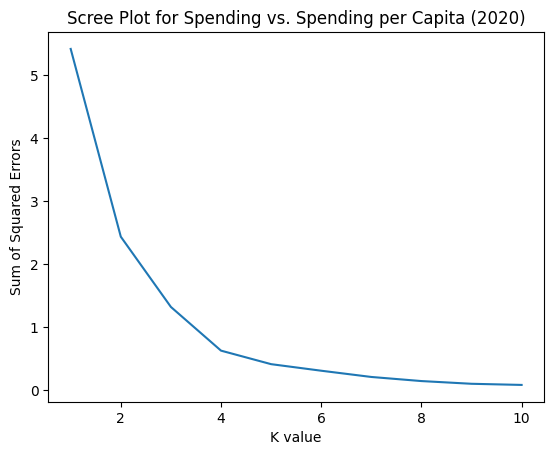


Optimal number of k clusters appears to be 4.


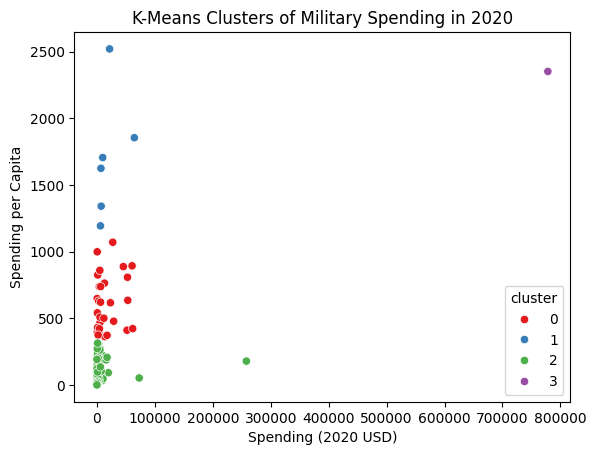

Spending (2020 USD)                                              \
                      count           mean           std            min   
cluster                                                                   
0                      30.0   17077.591354  20583.053357     405.790494   
1                       6.0   19443.362047  22861.507114    6095.708713   
2                     111.0    4859.185065  25405.739131       8.622460   
3                       1.0  778397.200000           NaN  778397.200000   

                                                                     \
                   25%            50%            75%            max   
cluster                                                               
0          2294.039665    5857.060906   26296.001003   61712.537169   
1          7023.251766    8624.225729   18857.070183   64558.400000   
2           130.010211     382.464677    2297.032353  257973.429834   
3        778397.200000  778397.200000  778397.200000  778397.200000   

        Spending per Capita               ... Percent of Government Spending  \
                      count         mean  ...                            75%   
cluster                                   ...                                  
0                      30.0   607.478618  ...                       0.048819   
1                       6.0  1706.721916  ...                       0.164503   
2                     111.0    80.061470  ...                       0.083508   
3                       1.0  2351.631858  ...                       0.081976   

                  Percent of GDP                                          \
              max          count      mean       std       min       25%   
cluster                                                                    
0        0.114776           30.0  0.019397  0.009272  0.006273  0.013892   
1        0.225050            6.0  0.059781  0.031979  0.020060  0.035460   
2        0.303027          111.0  0.017349  0.011699  0.000054  0.010087   
3        0.081976            1.0  0.037179       NaN  0.037179  0.037179   

                                       
              50%       75%       max  
cluster                                
0        0.018834  0.022515  0.042634  
1        0.059257  0.085398  0.098470  
2        0.014389  0.021697  0.066600  
3        0.037179  0.037179  0.037179  

[4 rows x 32 columns]


Observations:
  - Cluster 2 has the highest count with 111 distinct points as well as the lowest mean for total spending--this is most likely the low spending group
  - Cluster 3 only has point and the highest mean total mean spending--graphically, the cluster is a single point and appears to be an outlier compared to the rest of the data
  - Cluster 0 and 1 both have total spending means, but the Per Capita means differ substantially (607 vs. 1,707); this indicates that the K-means seemed to
  have separated them based on their per-capita spending
  - Cluster 3 has an std NaN because it only has one observation
  - General trend: Aside from Group 3, the clusters appear to overlap considerably on the X-axis, or Spending (2020 USD), so the clusters were morso
  informed by the differences in per-capita spending rather than total spending



,index,Spending (2020 USD),Percent of GDP,Percent of Government Spending,Spending per Capita,cluster
count,1.0,1.0,1.000000,1.000000,1.000000,1.0
mean,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
std,NaN,NaN,NaN,NaN,NaN,NaN
min,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
25%,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
50%,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
75%,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0
max,5540.0,778397.2,0.037179,0.081976,2351.631858,3.0


Based on the given stats, United states is the single observation in Group 3; contextually, this makes since we are the leading spenders in defense globally;
thus, K-means isolated it to a single cluster.


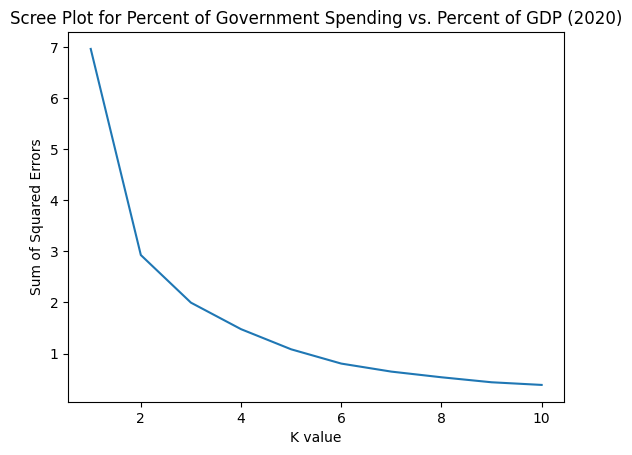


Optimal number of k clusters appears to be 3; harder to distinguish for these features.


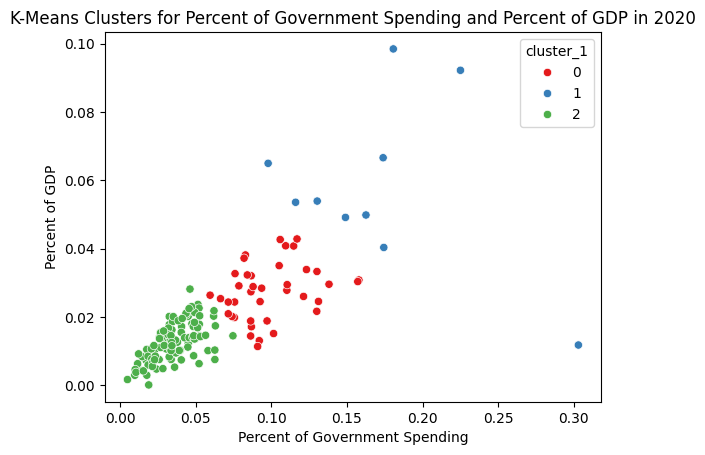

Spending (2020 USD)                                           \
                        count          mean            std         min   
cluster_1                                                                
0                        39.0  27387.150069  124489.244263   44.348098   
1                        10.0  12514.955945   19365.712246  633.960400   
2                        99.0   7611.174172   27958.296403    8.622460   

                                                                  \
                   25%          50%           75%            max   
cluster_1                                                          
0           310.624359  1157.372367   5786.787259  778397.200000   
1          2101.377796  6518.375529  10222.946276   64558.400000   
2           121.641398   567.650747   3910.107493  257973.429834   

          Spending per Capita              ... Percent of Government Spending  \
                        count        mean  ...                            75%   
cluster_1                                  ...                                  
0                        39.0  271.264618  ...                       0.112633   
1                        10.0  817.301890  ...                       0.179081   
2                        99.0  211.624304  ...                       0.047402   

                    Percent of GDP                                          \
                max          count      mean       std       min       25%   
cluster_1                                                                    
0          0.157918           39.0  0.027412  0.008191  0.011317  0.021254   
1          0.303027           10.0  0.058071  0.024867  0.011742  0.049297   
2          0.074624           99.0  0.012664  0.005681  0.000054  0.008393   

                                         
                50%       75%       max  
cluster_1                                
0          0.027781  0.032461  0.042810  
1          0.053729  0.066190  0.098470  
2          0.013191  0.016752  0.028132  

[3 rows x 32 columns]


Observations:
  - The graph suggests that cluster membership was influenced by both features rather than being driven primarily by one.
This is shown by how the clusters separate along both the x and y-axes, showing that oth Percent of Government Spending 
and Percent of GDP influencec cluster membership
  - There are fewer extreme observations than in the previous K-means clustering; this makes sense because the previous comparison
  in the scatter dealt with magnitudes of dollars, whereas this comparison utilized percentages
  - The highest count cluster--Cluster 2--still has the lowest Spending and Spending per Capita
  - General Trend: Focused on low->moderate->high spending-share pattern across the two features



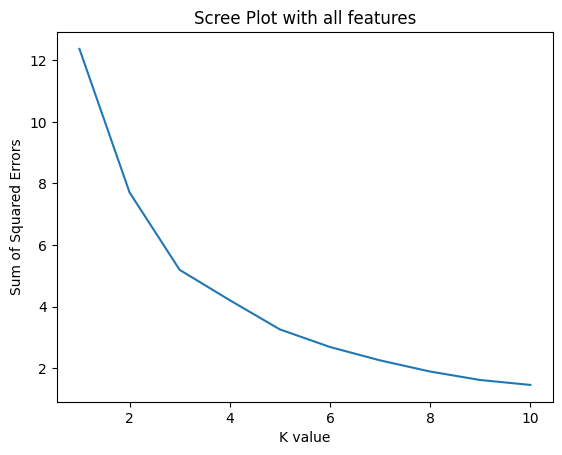


Optimal number of k clusters appears to be 5.


Spending (2020 USD)                                              \
                          count           mean           std            min   
cluster_all                                                                   
0                          86.0    4513.543790  27841.230783       8.622460   
1                           1.0  778397.200000           NaN  778397.200000   
2                          30.0    9073.543709  18135.032885     163.926877   
3                          26.0   15330.618681  18923.469359     405.790494   
4                           5.0   21878.058451  24674.937388    6095.708713   

                                                                         \
                       25%            50%            75%            max   
cluster_all                                                               
0                81.022976     288.061512    1138.618231  257973.429834   
1            778397.200000  778397.200000  778397.200000  778397.200000   
2               522.737081    1663.090134    8646.648849   72937.064048   
3              3176.345598    5857.060906   21818.934764   60675.039625   
4              6941.042345    9978.571429   21816.569767   64558.400000   

            Spending per Capita               ...  \
                          count         mean  ...   
cluster_all                                   ...   
0                          86.0    70.290644  ...   
1                           1.0  2351.631858  ...   
2                          30.0   215.920971  ...   
3                          26.0   612.677541  ...   
4                           5.0  1779.854530  ...   

            Percent of Government Spending           Percent of GDP            \
                                       75%       max          count      mean   
cluster_all                                                                     
0                                 0.053006  0.101501           86.0  0.012481   
1                                 0.081976  0.081976            1.0  0.037179   
2                                 0.136403  0.303027           30.0  0.034105   
3                                 0.044645  0.052209           26.0  0.016585   
4                                 0.180654  0.225050            5.0  0.067725   

                                                                         
                  std       min       25%       50%       75%       max  
cluster_all                                                              
0            0.005799  0.000054  0.007811  0.012532  0.016783  0.026340  
1                 NaN  0.037179  0.037179  0.037179  0.037179  0.037179  
2            0.011116  0.011742  0.027933  0.032148  0.040637  0.066600  
3            0.005525  0.006273  0.013689  0.015324  0.020431  0.028132  
4            0.028372  0.029429  0.053553  0.064961  0.092211  0.098470  

[5 rows x 32 columns]


Observations:
- Cluster 0 is the largest, with 86 countries, indicating that most countries fall into
  one broad four-variable spending profile.
- Cluster 1 contains only the United States, which remains isolated because of its extremely
  high total military spending.
- The four-variable model retains the extreme-spending pattern seen in Part 2 whilst
  incorporating the spending-share differences identified in Part 3.
- Compared with the two-variable models, the four-variable model produces more differentiated
  groups because cluster membership now depends simultaneously on absolute spending,
  per-capita spending, government-spending share, and GDP share.
- Cluster sizes remain uneven (86, 1, 30, 26, and 5), with one dominant group and several
  smaller groups representing less common spending profiles.


The k-MC algorithm showcased a few useful patterns. Most distinctly, large-cluster countries
trended towards relatively low military spending, while smaller clusters captured co

In [55]:
# Q2.1
df = pd.read_csv("A04-clustering/data/SIPRI Military Expenditure Database.csv")

# Make df calls just for when Year = 2020
df = df[df["Year"]==2020]

#Drop all null values
df_filtered = df.dropna()

# Verify all null values are dropped
print(f'Number of NaN values: {df_filtered.isna().sum()}')
display(df_filtered.describe())
display(df_filtered.head())

# --ADDITIONAL CLEANING (prior to min-max scaling)--

# Check for suspicious amounts of zeroes
zero_percentages = (df == 0).mean() * 100
print(f'Percentage of zeros: {zero_percentages}')

# Duplicate check
print(f'Number of duplicates: {df.duplicated().sum()}')

# Remove Year Column (Everything already filtered to Year 2020)
df_filtered = df_filtered.drop(columns=["Year"])
display(df_filtered.describe())

# Q2.2

# Scale the two features
features = ["Spending (2020 USD)","Spending per Capita"]
unscaled = df_filtered.loc[:, features]
mins = unscaled.min()
ranges = unscaled.max() - mins
X_spending = (unscaled - mins) / ranges
X_spending.agg(["min", "max"])


# Create Scree plot for Spending (2020 USD) and Spending per Capita
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_spending).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for Spending vs. Spending per Capita (2020)")
plt.show()

print("""
Optimal number of k clusters appears to be 4.""")

# Create Scatter plot with hues

# Re-run with k = 4
model = KMeans(
    n_clusters=4,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_spending)

# Make cluster labels a column
df_filtered['cluster']=model.labels_

# Create scatter for both filtered and filtered + normalized datasets

# Filtered Plot
sns.scatterplot(
    data=df_filtered,
    x="Spending (2020 USD)",
    y="Spending per Capita",
    hue="cluster",
    palette="Set1"
)

plt.title("K-Means Clusters of Military Spending in 2020")
plt.show()

# Describe Table
display(df_filtered.groupby("cluster")[
    [
        "Spending (2020 USD)",
        "Spending per Capita",
        "Percent of Government Spending",
        "Percent of GDP"
    ]
].describe())

print("""
Observations:
  - Cluster 2 has the highest count with 111 distinct points as well as the lowest mean for total spending--this is most likely the low spending group
  - Cluster 3 only has point and the highest mean total mean spending--graphically, the cluster is a single point and appears to be an outlier compared to the rest of the data
  - Cluster 0 and 1 both have total spending means, but the Per Capita means differ substantially (607 vs. 1,707); this indicates that the K-means seemed to
  have separated them based on their per-capita spending
  - Cluster 3 has an std NaN because it only has one observation
  - General trend: Aside from Group 3, the clusters appear to overlap considerably on the X-axis, or Spending (2020 USD), so the clusters were morso
  informed by the differences in per-capita spending rather than total spending
""")

# Find stats on the United States:
display(df_filtered[df_filtered['Country']=='United States of America'].describe())

print("""Based on the given stats, United states is the single observation in Group 3; contextually, this makes sense because we are the leading spenders in defense globally;
thus, K-means isolated it to a single cluster.""")

# Q2.3

# Scale the two features
features_1 = ["Percent of Government Spending","Percent of GDP"]
unscaled_1 = df_filtered.loc[:, features_1]
mins_1 = unscaled_1.min()
ranges_1 = unscaled_1.max() - mins_1
X_government_spending = (unscaled_1 - mins_1) / ranges_1
X_government_spending.agg(["min", "max"])


# Create Scree plot for Spending (2020 USD) and Spending per Capita
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_government_spending).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for Percent of Government Spending vs. Percent of GDP (2020)")
plt.show()

print("""
Optimal number of k clusters appears to be 3; harder to distinguish for these features.""")

# Create Scatter plot with hues

# Re-run with k = 3
model = KMeans(
    n_clusters=3,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_government_spending)

# Make cluster labels a column
df_filtered['cluster_1']=model.labels_

# Create scatter plot
sns.scatterplot(
    data=df_filtered,
    x="Percent of Government Spending",
    y="Percent of GDP",
    hue="cluster_1",
    palette="Set1"
)

plt.title("K-Means Clusters for Percent of Government Spending and Percent of GDP in 2020")
plt.show()

# Describe Table
display(df_filtered.groupby("cluster_1")[
    [
        "Spending (2020 USD)",
        "Spending per Capita",
        "Percent of Government Spending",
        "Percent of GDP"
    ]
].describe())


print("""
Observations:
  - The graph suggests that cluster membership was influenced by both features rather than being driven primarily by one.
This is shown by how the clusters separate along both the x and y-axes, showing that both Percent of Government Spending
and Percent of GDP influence cluster membership
  - There are fewer extreme observations than in the previous K-means clustering; this makes sense because the previous comparison
  in the scatter dealt with magnitudes of dollars, whereas this comparison utilized percentages
  - The highest count cluster--Cluster 2--still has the lowest Spending and Spending per Capita
  - General Trend: Focused on low->moderate->high spending-share pattern across the two features
""")

# Q2.4
features_all = [
    'Spending (2020 USD)',
    'Spending per Capita',
    'Percent of Government Spending',
    'Percent of GDP'
]

unscaled_all = df_filtered[features_all]

mins = unscaled_all.min()
ranges = unscaled_all.max() - mins

X_all = (unscaled_all - mins) / ranges

# Scree Plot for all features
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_all).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot with all features")
plt.show()

print("""
Optimal number of k clusters appears to be 5.""")

# Create Scatter plot with hues

# Re-run with k = 5
model = KMeans(
    n_clusters=5,
    max_iter=300,
    n_init=10,
    random_state=0
).fit(X_all)

# Make cluster labels a column
df_filtered['cluster_all']=model.labels_

# Describe Table
display(df_filtered.groupby("cluster_all")[
    [
        "Spending (2020 USD)",
        "Spending per Capita",
        "Percent of Government Spending",
        "Percent of GDP"
    ]
].describe())

print("""
Observations:
- Cluster 0 is the largest, with 86 countries, indicating that most countries fall into
  one broad four-variable spending profile.
- Cluster 1 contains only the United States, which remains isolated because of its extremely
  high total military spending.
- The four-variable model retains the extreme-spending pattern seen in Part 2 whilst
  incorporating the spending-share differences identified in Part 3.
- Compared with the two-variable models, the four-variable model produces more differentiated
  groups because cluster membership now depends simultaneously on absolute spending,
  per-capita spending, government-spending share, and GDP share.
- Cluster sizes remain uneven (86, 1, 30, 26, and 5), with one dominant group and several
  smaller groups representing less common spending profiles.
""")

# Q2.5

print("""
The k-MC algorithm showcased a few useful patterns. Most distinctly, large-cluster countries
trended towards relatively low military spending, while smaller clusters captured countries with higher spending
per capita or higher military spending as a share of GDP and government spending. The analysis also identified an extreme
high-spending country--the United States--that separated from the rest of the data. In totality, the clustering showed that countries
differ not only in how much they spend, but also in how large that spending is relative to their population and economy.""")


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]